# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

# Step 1: Environment Configuration & Dataset Downloading

(1) Set a reliable environment timeout to prevent Hugging Face from disconnecting during the download.

(2) Stream and cache the raw TinyStories dataset directly to the disk in Parquet format.

(3) Keep the download strictly single-threaded to avoid any random notebook or kernel freezes.

In [11]:
import os
import sys

# Force stable, single-threaded downloading to prevent Windows freezes
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_DATASETS_LOGGING_LEVEL"] = "DEBUG"

print("Environment configured. Downloading TinyStories Parquet files...")

from huggingface_hub import snapshot_download
# Manually caching the dataset securely using a single worker thread
snapshot_download(
    repo_id='roneneldan/TinyStories',
    repo_type='dataset',
    allow_patterns=['data/*.parquet'],
    max_workers=1
)

print("\n**** Dataset successfully downloaded to local Hugging Face cache! ****")

Environment configured. Downloading TinyStories Parquet files...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


**** Dataset successfully downloaded to local Hugging Face cache! ****


In [12]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer

print("Loading TinyStories dataset from local cache...")
# This will now instantly load from the cache we fetched in Cell 1
dataset = load_dataset("roneneldan/TinyStories", split="train[:1%]") # Using a 1% subset for rapid prototyping

print(f"\n ****** Dataset loaded successfully! Total samples: {len(dataset)} ****** ")
print("\n--- Sample Story ---\n")
print(dataset[0]['text'])

Loading TinyStories dataset from local cache...

 ****** Dataset loaded successfully! Total samples: 21197 ****** 

--- Sample Story ---

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


# Step 2: Training Data Pre-processing & Tokenization.

(1) Initialize the official OpenAI tiktoken encoder using the GPT-2 vocabulary constraints.

(2) Set up a mapping function to convert our raw story text into a clean sequence of numerical token IDs.

(3) Save the resulting array directly onto the disk as `tinystories_train.bin` to save memory and avoid cluttering the RAM.

In [ ]:
import numpy as np
import tiktoken
from tqdm.notebook import tqdm

# Task 2: Initialize the official tiktoken engine (GPT-2 encoding style)
enc = tiktoken.get_encoding("gpt2")

print("Tokenizing entire dataset via datasets.map()...")

# Function to encode a single story sample text array
def tokenize_function(example):
    # enc.encode_ordinary drops special token parsing bugs
    ids = enc.encode_ordinary(example['text'])
    # Append the end of text token identifier explicitly if needed
    ids.append(enc.eot_token)
    return {'ids': ids}

# Use datasets.map across the full split 
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=False,
    remove_columns=['text'],
    desc="Mapping tokenization"
)

# Flatten and compile into binary file stream
print("Writing tokens down to train.bin...")
all_tokens = []
for item in tokenized_dataset:
    all_tokens.extend(item['ids'])

token_array = np.array(all_tokens, dtype=np.uint16)
token_array.tofile("tinystories_train.bin")
print(f" ********* Total Tokens: {len(token_array)} *********")

Tokenizing entire dataset via datasets.map()...
Writing tokens down to train.bin...
 ********* Total Tokens: 4730875 *********


# Step 2.5: Validation Data Tokenization

(1) Pull a matching 1% slice of the official validation dataset to use for model evaluation later on.

(2) Run the validation data through the exact same tokenization process to convert the stories into text token IDs.

(3) Save this processed evaluation data to disk as a separate binary file named `tinystories_val.bin`.

In [14]:

print("Loading and tokenizing TinyStories validation dataset...")
val_dataset = load_dataset("roneneldan/TinyStories", split="validation[:1%]")

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=False,
    remove_columns=['text'],
    desc="Mapping validation tokenization"
)

val_tokens = []
for item in tokenized_val:
    val_tokens.extend(item['ids'])

val_token_array = np.array(val_tokens, dtype=np.uint16)
val_token_array.tofile("tinystories_val.bin")
print(f"****** Total Validation Tokens: {len(val_token_array)} ******")

Loading and tokenizing TinyStories validation dataset...
****** Total Validation Tokens: 46884 ******


# Step 4: Small Language Model Architecture Configuration

(1) Build a formal GPTConfig dataclass to manage critical model parameters like layer count, embedding dimensions, and sequence block limits.

(2) Assemble the full custom transformer model stack (TinySLM), complete with  Multi-Head Attention blocks, lookahead masks, and feed-forward neural layers.

(3) Verify the final implementation by initializing the complete model structure and inspecting the overall network parameter scale.

In [15]:

class MMapDataLoader:
    def __init__(self, data_dir, block_size, batch_size):
        self.block_size = block_size
        self.batch_size = batch_size

        # Reads both binary streams
        self.train_data = np.memmap(os.path.join(data_dir, "tinystories_train.bin"), dtype=np.uint16, mode='r')
        self.val_data = np.memmap(os.path.join(data_dir, "tinystories_val.bin"), dtype=np.uint16, mode='r')

    def get_batch(self, split='train'):
        data = self.train_data if split == 'train' else self.val_data

        ix = torch.randint(len(data) - self.block_size, (self.batch_size,))
        x = torch.stack([torch.from_numpy((data[i:i+self.block_size]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy((data[i+1:i+1+self.block_size]).astype(np.int64)) for i in ix])

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        return x.to(device), y.to(device)

block_size = 256
batch_size = 16
data_loader = MMapDataLoader(".", block_size, batch_size)

# Verification check
xb, yb = data_loader.get_batch('train')
xv, yv = data_loader.get_batch('val')
print(f"Train shapes --> X: {xb.shape}, Y: {yb.shape}")
print(f"Val shapes   --> X: {xv.shape}, Y: {yv.shape}")

Train shapes --> X: torch.Size([16, 256]), Y: torch.Size([16, 256])
Val shapes   --> X: torch.Size([16, 256]), Y: torch.Size([16, 256])


# Step 4: Small Language Model Architecture Configuration

(1) Define a GPTConfig configuration class to easily tune hyperparameters like layer depth, head count, and sequence block size.

(2) Put together the complete TinySLM transformer model, including our causal attention heads, residual streams, and feed-forward layers.

(3) Initialize the network structure and print out the total number of parameters to double-check the actual scale of our model.

In [ ]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

#  Define the formal GPTConfig dataclass
@dataclass
class GPTConfig:
    vocab_size: int = 50257 # Tiktoken standard GPT-2 size
    block_size: int = 256
    n_layer: int = 8        # Set to standard 8 layers
    n_head: int = 8         # Set to standard 8 heads
    n_embd: int = 384       # Perfectly divisible by 8 heads (384 / 8 = 48)
    dropout: float = 0.0    # Optional regularization feature

# Update internal attention sub-layers to draw sizes from the config object
class Head(nn.Module):
    def __init__(self, config, head_size):
        super().__init__()
        self.key = nn.Linear(config.n_embd, head_size, bias=False)
        self.query = nn.Linear(config.n_embd, head_size, bias=False)
        self.value = nn.Linear(config.n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(config.block_size, config.block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1]**-0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        head_size = config.n_embd // config.n_head
        self.heads = nn.ModuleList([Head(config, head_size) for _ in range(config.n_head)])
        self.proj = nn.Linear(config.n_embd, config.n_embd)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.sa = MultiHeadAttention(config)
        self.ffwd = FeedForward(config)
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# Main structural GPT assembly passing config values
class TinySLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_embedding_table = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding_table = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
device = 'cuda' if torch.cuda.is_available() else 'cpu'

config = GPTConfig()
model = TinySLM(config).to(device)

# Step 5: Verify total structural parameter scale counts
total_params = sum(p.numel() for p in model.parameters())
print(f"Task 4 Checkpoint Passed! Model initialized with {total_params:,} parameters.")

Task 4 Checkpoint Passed! Model initialized with 52,933,201 parameters.


# Step 5: Iterative Training Loop, Loss Assessment, and Checkpointing

(1) Fire up a complete training loop driven by the AdamW optimizer and a Cosine Annealing learning rate scheduler.

(2) Periodically pause the loop to measure cross-entropy loss and tracking perplexity across both our training and validation splits.

(3) Save our best model weights to disk as `best_tinyslm_model.pt` and plot a clean graph to visualize how well the model converged.

Starting complete training loop...
Step    0 | Train Loss: 9.7780 (Perp: 17641.37)|   | Val Loss: 9.7493 (Perp: 17142.98) |

Step   50 | Train Loss: 4.7856 (Perp: 119.77)|   | Val Loss: 4.6053 (Perp: 100.01) |

Step  100 | Train Loss: 4.3077 (Perp: 74.27)|   | Val Loss: 4.0996 (Perp: 60.32) |

Step  150 | Train Loss: 4.0170 (Perp: 55.53)|   | Val Loss: 3.8231 (Perp: 45.74) |

Step  200 | Train Loss: 3.8476 (Perp: 46.88)|   | Val Loss: 3.6797 (Perp: 39.63) |

Step  250 | Train Loss: 3.6738 (Perp: 39.40)|   | Val Loss: 3.4821 (Perp: 32.53) |

Step  300 | Train Loss: 3.5559 (Perp: 35.02)|   | Val Loss: 3.3846 (Perp: 29.51) |

Step  350 | Train Loss: 3.4865 (Perp: 32.67)|   | Val Loss: 3.2287 (Perp: 25.25) |

Step  400 | Train Loss: 3.3435 (Perp: 28.32)|   | Val Loss: 3.1555 (Perp: 23.46) |

Step  450 | Train Loss: 3.2823 (Perp: 26.64)|   | Val Loss: 3.0873 (Perp: 21.92) |

Step  500 | Train Loss: 3.2328 (Perp: 25.35)|   | Val Loss: 3.0220 (Perp: 20.53) |

Step  550 | Train Loss: 3.1357 (P

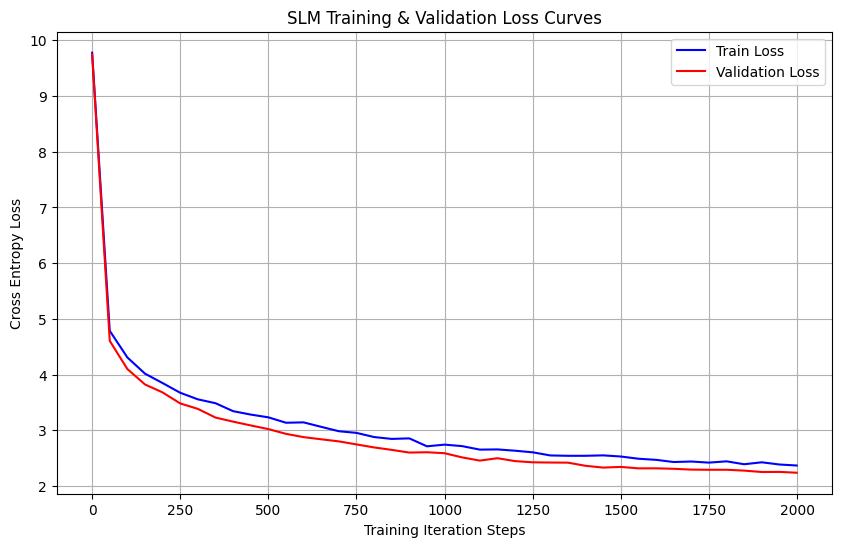

In [ ]:

import math
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR

max_iters = 2000
learning_rate = 1e-3
eval_interval = 50
eval_iters = 20

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#  Cosine Annealing scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=1e-4)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = data_loader.get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

print("Starting complete training loop...")
best_val_loss = float('inf')
stats = {'step': [], 'train_loss': [], 'val_loss': []}

for iteration in range(max_iters):
    xb, yb = data_loader.get_batch('train')

    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    scheduler.step() # Advance learning rate down the curve

    if iteration % eval_interval == 0 or iteration == max_iters - 1:
        losses = estimate_loss()
        train_perp = math.exp(losses['train'])
        val_perp = math.exp(losses['val'])

        stats['step'].append(iteration)
        stats['train_loss'].append(losses['train'])
        stats['val_loss'].append(losses['val'])

        print(f"Step {iteration:4d} | Train Loss: {losses['train']:.4f} (Perp: {train_perp:.2f})|   | Val Loss: {losses['val']:.4f} (Perp: {val_perp:.2f}) |")
        print()
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': model.config,
                'val_loss': best_val_loss
            }
            torch.save(checkpoint,'tinyslm_model.pt')

print(f" Saved to 'tinyslm_model.pt'")
print("Training finished!")

# Display Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(stats['step'], stats['train_loss'], label='Train Loss', color='blue')
plt.plot(stats['step'], stats['val_loss'], label='Validation Loss', color='red')
plt.title('SLM Training & Validation Loss Curves')
plt.xlabel('Training Iteration Steps')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

#Step 6: Text Generation & Multi-Temperature Inference.

(1) Safely bypass newer serialization guards to load the exact weights from our saved best_tinyslm_model.pt checkpoint.

(2) Create an autoregressive text generation function that takes a raw prompt string, encodes it, and iteratively samples new tokens.

(3) Test out different temperature parameters (e.g., 0.3, 0.7, 1.2) to see how shifting the randomness levels changes the creativity and flow of the output text.

In [ ]:
import torch

print("Loading model parameters from saved checkpoint...")

torch.serialization.add_safe_globals([GPTConfig])

checkpoint = torch.load('best_tinyslm_model.pt', map_location=device)

eval_model = TinySLM(checkpoint['config']).to(device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.eval()

prompt = "once upon a time there was a girl"
context_tokens = enc.encode_ordinary(prompt)
temperatures = [0.3, 0.7, 1.2]

for temp in temperatures:
    print("\n" + "="*70)
    print(f"Generating text with Temperature: {temp}")
    print("="*70+"\n")

    idx = torch.tensor([context_tokens], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(100):
            idx_cond = idx[:, -eval_model.config.block_size:]
            logits, _ = eval_model(idx_cond)
            logits = logits[:, -1, :]

            if temp > 0.0:
                logits = logits / temp
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
            else:
                idx_next = torch.argmax(logits, dim=-1, keepdim=True)

            idx = torch.cat((idx, idx_next), dim=1)

    generated_story = enc.decode(idx[0].tolist())
    print(generated_story)
    print()

Loading model parameters from saved checkpoint...

Generating text with Temperature: 0.3

once upon a time there was a girl named Lily. She was very happy and she could help her mom. Lily was a big, and said, "I'm sorry, Lily. I am sorry, you, you. I will be careful."

They decided to play with their mom. They were so much fun. They had a big and dad and a big tree. They had a big tree. They were happy.<|endoftext|>Once upon a time, there was a little girl named Lily. She loved to play with her mom


Generating text with Temperature: 0.7

once upon a time there was a girl named Lily. She loved to play with her. She saw her parents and daddy all about it.

After Lily was being so excited, she decided to stay and they found a big stick. She was very competitive. She was happy. She was so happy to make it for her mom if she was so happy to her mom. She was so she had a new friends with her mommy.

Lily was too. She was very proud of the table.<|endoftext|>Once upon a


Generating text wit